Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on $Pr$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [36]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle
from scipy.sparse.linalg import inv as spinv
from scipy.sparse import block_diag

from IPython.display import display, Latex
import qil_helpers.Ben.General as Ben

In [37]:
plt.rc('xtick', labelsize=16) 
plt.rc('ytick', labelsize=16) 
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)

In [38]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [39]:
#M tensor ground state
M = np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*spin.h#convert kHz/G to MHz/T  to J/T      #/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))
eRot= 'ZYZ'

#rotated tensors
M_rot = np.array([-99.7,55.7,-40])*np.pi/180
#M_rot = np.array([112,35.68,101.54])*np.pi/180

#M_rot=np.array([0,0,0])
Q_rot = np.array([-94,58.1,-20.7])*np.pi/180
#Q_rot = np.array([62.1,31.81,93.94])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str=eRot,dumb=True)#ZYZ
Q_G = spin.tensorRotation(Q,Q_rot,str=eRot,dumb=True)

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
#ground.setM(M_G)

az = 2.1
alt = 0#(90-87.8)
rt = np.array([alt,az])*np.pi/180
RB = spin.sphereUnit(rt,unit=False,str='zy')
#M_G=spin.tensorRotation(M,np.array([2,5,0])*np.pi/180,str=eRot)
#M_G=RB@M_G@RB.T


ground.setM(M_G)
ground.setgN(None)
#print(ground.H.shape)

[[-0.5624  0.      0.    ]
 [ 0.      0.5624  0.    ]
 [ 0.      0.      4.445 ]]
Q [[ 0.40747302 -0.00924087 -0.46728936]
 [-0.00924087  3.10033234 -2.15607217]
 [-0.46728936 -2.15607217  0.93719464]]
M [[ 2.06822404e-26  6.11138919e-27 -4.98762664e-27]
 [ 6.11138919e-27  5.74949763e-26 -2.61381666e-26]
 [-4.98762664e-27 -2.61381666e-26  3.76272292e-26]]


In [40]:
# ground=spin.hamilFromYAML("./ion_params/Pr_YSO.yml")

C:\Users\neb16\AppData\Local\Temp/ipykernel_15272/2050134158.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  Fpx[i,:]= ground.firstOrderEnergySensitivity(VG,A[0])#+ground.firstOrderEnergySensitivity(VG,Ay)#x =


17.310310645043383 10.187833639634672
[-27.9007349  -27.9007349  -10.59042426 -10.59042426  -0.40259062
  -0.40259062]
Es: [-57.51691533 -38.05773829 -23.46642906  -5.88040586  13.38217222
  33.75181676]


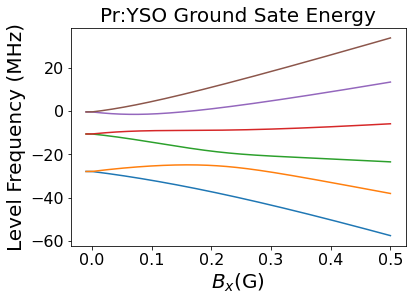

[ 1  2  3  4  5  8  9 10 11 15 16 17 22 23 29]
[ 1  2  3  4  5  8  9 10 11 15 16 17 22 23 29]
[ 1  2  3  4  5  8  9 10 11 15 16 17 22 23 29]


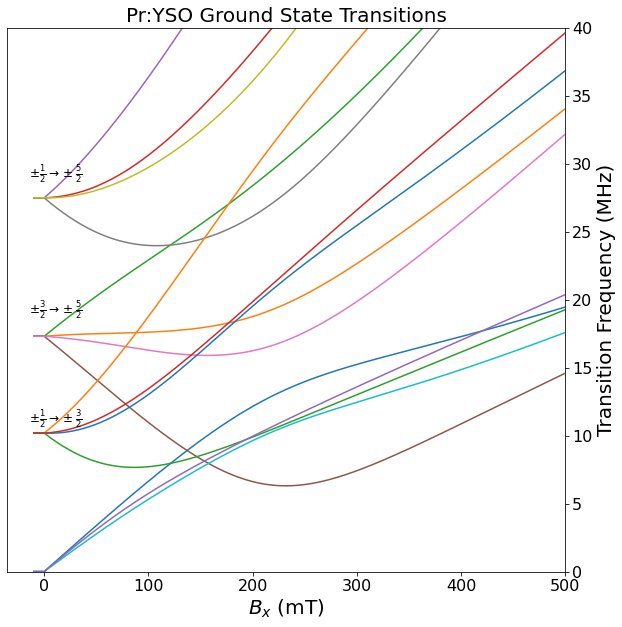

In [41]:
%matplotlib inline
#Zero Field
from scipy.spatial.transform import Rotation


Rx = lambda a : np.matrix([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
Ry = lambda a : np.matrix([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])
Rz = lambda a : np.matrix([[np.cos(a),-np.sin(a),0],[np.sin(a),np.cos(a),0],[0,0,1]])



 #convert spherical Magnetic field to cartesian coords.
#print(np.zeros(20),np.linspace(0,0.2,100))
#theta,phi = spin.eulerToSphere(Q_rot,str='ZXZ')
#RM = Rotation.from_euler('yz',[theta,phi]).as_matrix()
RM = np.asmatrix(Rotation.from_euler(eRot,M_rot).as_matrix())
#RM=spin.rotMatrixDumb(M_rot)
#print(RM)

#print(RB)
Bf = 0.5

#Back and foward propgation
xs=np.linspace(0,Bf,500)
xs = np.concatenate((np.zeros(20),xs,Bf*np.ones(20)))


#Calculate our hamiltonian at this B Field

F=np.zeros((len(xs),ground.dim))
Fpx=np.zeros((len(xs),ground.dim))
Fppx=np.zeros((len(xs),ground.dim,3,3),dtype = np.csingle)

Ax=ground.nuclearZeeman(np.matrix([1,0,0]).T)
Ay=ground.nuclearZeeman(np.matrix([0,1,0]).T)
Az=ground.nuclearZeeman(np.matrix([0,0,1]).T)

Is = spin.spinOperator(Ispin,matricies=True)
A = spin.genAMatrix(M_G,Is)

for i,x in enumerate(xs):
    B = np.matrix([1,0,0]).T*x
    #print(B)
    # B=RM@B
    #convert spherical Magnetic field to cartesian coords.
    # B =RB@B
    # B=spin.sphereCart(x,*rt)
    #print(B)
            
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F[i,:]=FG*1E3
    Fpx[i,:]= ground.firstOrderEnergySensitivity(VG,A[0])#+ground.firstOrderEnergySensitivity(VG,Ay)#x = 
    Fppx[i,:] = ground.curvatureCalculation(A[0],A[1],A[2],VG,FG,indiv=False).T
#print(F[0][])
print(F[0][2]-F[0][0],F[0][4]-F[0][2])

xs[0:20]=np.linspace(-0.01,0,20)
# xs[-20:]=np.linspace(Bf,Bf+0.02,20)
print(F[0,:])
#
plt.plot(xs,F)
plt.xlabel("$B_{x}$(G)")
plt.ylabel("Level Frequency (MHz)")
plt.savefig("../images/Pr_level.pgf",bbox_inches='tight')
plt.savefig("../images/Pr_level.png",bbox_inches='tight')
plt.title("Pr:YSO Ground Sate Energy")

print("Es:", F[-1,:])

plt.show()
plt.close()


Ts = spin.eachElemFunc(F,F,ax=1)
Tds=spin.eachElemFunc(Fpx,Fpx,ax=1)
Tdds=spin.eachElemFunc(Fppx,Fppx,ax=1)

fig = plt.figure(figsize=(10,10))

#Clip to only single transition direction
half=np.squeeze(np.argwhere(np.sign(Ts[0,:])==1))#int((ground.dim**2)/2)-1
Ts=Ts[:,half]
Tds=Tds[:,half]
Tdds=Tdds[:,half,:,:]


print(half)
n=6
excl=np.concatenate([np.arange(n*i,n*i+i+1) for i in range(n)])
inc=np.concatenate([np.arange(n*i+1+i,n*(i+1)) for i in range(n)])
print(inc)
print(np.setdiff1d(np.arange(0,n**2),excl))
#print(half,ground.dim)
#print(Ts.shape)
plt.plot(xs*1E3,Ts)
plt.ylim([0,40])
plt.xlim([None,Bf*1E3])
#plt.gca().set_prop_cycle(None)
#plt.plot(xs*1E4,Ts[119,:]*np.ones((len(xs),len(Ts[1,:]))),'--')
plt.xlabel("$B_{x}$ (mT)")
plt.ylabel("Transition Frequency (MHz)")

plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{5}{2}$",(-10,28),(-15,29),fontsize='large')
plt.annotate(r"$\pm\frac{3}{2}\rightarrow\pm\frac{5}{2}$",(-10,18),(-15,19),fontsize='large')
plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{3}{2}$",(-10,12),(-15,11),fontsize='large')
plt.annotate("Spin Flip",(-50,1),(-15,5),fontsize='large')

#plt.plot([732,732],[0,50],'--')
ax=plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
plt.title("Pr:YSO Ground State Transitions")
# plt.savefig("../images/Pr_trans.pgf",bbox_inches='tight')
# plt.savefig("../images/Pr_trans.png",bbox_inches='tight')
Ben.goodFigSave("../images/","Pr_trans.pgf",final=True)
Ben.goodFigSave("../images/","Pr_trans.png",final=True)

plt.show()
plt.close()

print()

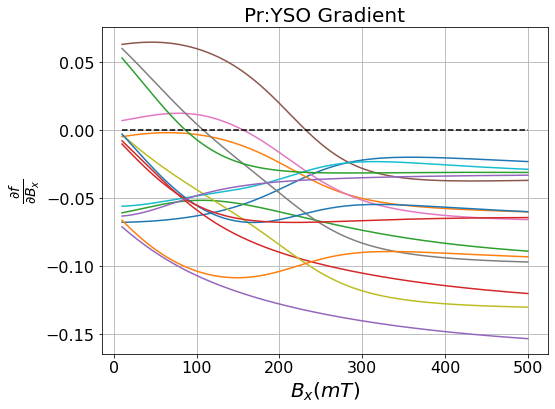

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


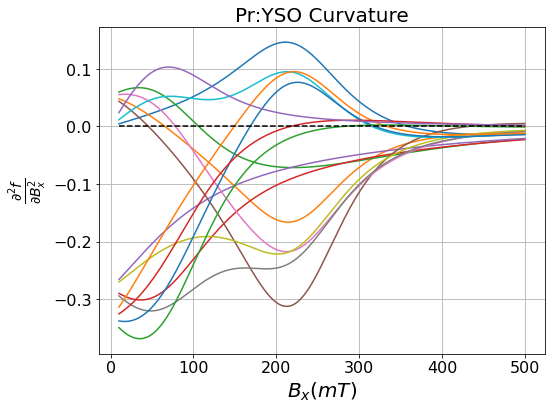

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


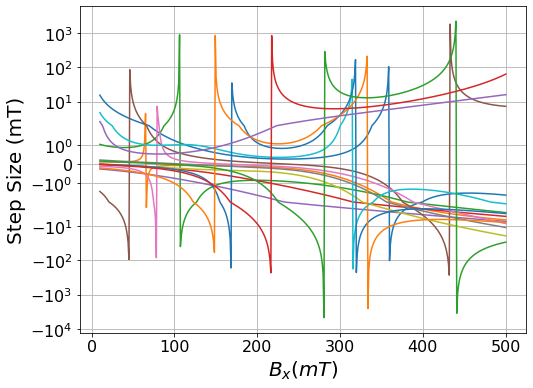

In [42]:
fig = plt.figure(figsize=(8,6))
slc=slice(30,-1)
#slc=slice(0,-1)
numr=np.gradient(Ts[slc],axis=0)/(Bf*10)
calc = Tds[slc]
xt = xs[slc]
norm = lambda x: np.abs(x/np.max(x))

#plt.plot(xt*1E3,(numr))
#plt.gca().set_prop_cycle(None)
plt.title("Pr:YSO Gradient")
plt.plot(xt*1E3,(calc))
plt.plot(xt*1E3,np.zeros_like(xt),'k--')
plt.xlabel(r"$B_{x}(mT)$")
plt.ylabel(r"$\frac{\partial f}{\partial B_{x}}$")
plt.grid()
Ben.goodFigSave("../images","gradient.png",final=True)
plt.show()
plt.close()



numrdd=np.gradient(numr,axis=0)
calcdd=(Tdds[slc,:,0,0])
# fig = plt.figure(figsize=(10,10))
fig = plt.figure(figsize=(8,6))

plt.plot(xt*1E3,calcdd)
plt.plot(xt*1E3,np.zeros_like(xt),'k--')

plt.title("Pr:YSO Curvature")
#plt.yscale('symlog')
plt.xlabel(r"$B_{x}(mT)$")
plt.ylabel(r"$\frac{\partial^{2} f}{\partial B_{x}^{2}}$")

plt.grid()

Ben.goodFigSave("../images","curve.png",final=True)

plt.show()
plt.close()
# fig = plt.figure(figsize=(10,10))
fig = plt.figure(figsize=(8,6))

starts=np.tile(xt,(calc.shape[1],1)).T
C=1/calcdd
# C[np.abs(C)>1000]=1
plt.xlabel(r"$B_{x}(mT)$")
plt.ylabel(r"Step Size (mT)")

plt.plot(xt*1E3,-calc*C)
plt.grid()

plt.yscale('symlog')

Ben.goodFigSave("../images","step.png",final=True)


plt.show()
plt.close()

# plt.quiver(numr.T,-calc/calcdd,np.zeros_like(starts))
# plt.show()
# plt.close
#raise ValueError("Stop You've violate the law!!!")

In [43]:
B = np.matrix([664,372,971]).T*1E-4
HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
FG,VG = ground.getEigFreq(HG)
F=FG*1E3


Ts = spin.eachElemFunc(F,F,ax=0)

#Elevels=[r"$-\frac{1}{2}$",r"$+\frac{1}{2}$",r"$-\frac{3}{2}$",r"$+\frac{3}{2}$",r"$-\frac{5}{2}$",r"$+\frac{5}{2}$"]
#Elevels=[r"$+\frac{1}{2}$",r"$-\frac{1}{2}$",r"$+\frac{3}{2}$",r"$-\frac{3}{2}$",r"$+\frac{5}{2}$",r"$-\frac{5}{2}$"]
#Elevels=[r"$+\frac{5}{2}$",r"$+\frac{3}{2}$",r"$+\frac{1}{2}$",r"$-\frac{1}{2}$",r"$-\frac{3}{2}$",r"$-\frac{5}{2}$"]
Elevels=[r"$-\frac{5}{2}$",r"$+\frac{5}{2}$",r"$-\frac{3}{2}$",r"$+\frac{3}{2}$",r"$-\frac{1}{2}$",r"$+\frac{1}{2}$"]
a=np.repeat(Elevels,len(Elevels))
b=np.tile(Elevels,len(Elevels))



for i,t in enumerate(Ts):
    display(Latex(r"%s : %s $\rightarrow$ %s : %s"%(i,a[i],b[i],t)))


#raise SystemExit("Stop! You've Violated the Law!")


#print(B)
#B=RM@B
#convert spherical Magnetic field to cartesian coords.
#B =RB@B
#B=spin.sphereCart(x,*rt)
#print(B)
        



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# 2D example

In [44]:
Is = spin.spinOperator(Ispin,matricies=True)
As = spin.genAMatrix(M_G,Is)


In [45]:

#
Is = spin.spinOperator(Ispin,matricies=True)
As = spin.genAMatrix(M_G,Is)

def singleLoop(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l])
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    Fpp = ground.curvatureCalculationNaive(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp,Fpp)


def singleTrans(X,Y,Z,t):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG[t]*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG[:,t],As[l])
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False,transitions=[t]).T#*spin.muN
    
    return (F,Fp,Fpp)


def singleLoopNoCurve(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l])
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    #Fpp = ground.curvatureCalculationNaive(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp)




#our loop
def sweep(Bs):
    #sets the default dynamic term as both electronic and nuclear zeeman
    #F = ground.initSweep(Bx,By,Bz)
    #Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    #Fp=ground.initSweep(Bx,By,Bz,[ground.dim,3])
    ##Fpp = ground.initSweep(Bx,By,Bz,ground.dim)
    #Fpp = ground.initSweep(Bx,By,Bz,fdim=[ground.dim,3,3])
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)

    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:],Fpp[i,:] = singleLoop(Bs[i,0],Bs[i,1],Bs[i,2])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)
    #return F,Fp,Fpp

def sweepSingleTrans(Bs,s,e):
    Fs=np.zeros(len(Bs))
    Fps=np.zeros((len(Bs),3),dtype = np.csingle)
    Fpps=np.zeros((len(Bs),3,3),dtype = np.csingle)

    Fe=np.zeros_like(Fs)
    Fpe=np.zeros_like(Fps)
    Fppe=np.zeros_like(Fpps)
    

    for i in range(Bs.shape[0]):
        Fs[i],Fps[i,:],Fpps[i,:] = singleTrans(Bs[i,0],Bs[i,1],Bs[i,2],s)
        Fe[i],Fpe[i,:],Fppe[i,:] = singleTrans(Bs[i,0],Bs[i,1],Bs[i,2],e)
    #return all transion based values         
    return Fe-Fs,Fpe-Fps,Fppe-Fpps
#spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)


def sweepNoCurve(Bs):
    #sets the default dynamic term as both electronic and nuclear zeeman
    #F = ground.initSweep(Bx,By,Bz)
    #Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    #Fp=ground.initSweep(Bx,By,Bz,[ground.dim,3])
    ##Fpp = ground.initSweep(Bx,By,Bz,ground.dim)
    #Fpp = ground.initSweep(Bx,By,Bz,fdim=[ground.dim,3,3])
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    
    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:] = singleLoopNoCurve(Bs[i,0],Bs[i,1],Bs[i,2])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1)
    #return spin.eachElemFunc(F,F,ax=1),Fp

def sweepAltGradient(Bs):
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    
    for i in range(Bs.shape[0]):
            #convert spherical Magnetic field to cartesian coords.
        B = np.matrix(Bs[i,0],Bs[i,1],Bs[i,2]).T
    
        #Calculate our hamiltonian at this B Field
        HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

        #get the eigen frequencies and vectors at this B field
        FG,VG = ground.getEigFreq(HG)
        F=FG*1E3
    T=spin.eachElemFunc(F,F,ax=1)
    
    return T
    
def printRegionsXY(CR):
    for R in CR:
        #print(R)
        h=R[1][1]-R[1][0]
        w = R[0][1]-R[0][0]
        #print(R[0:1][0],w,h)
        ax=plt.gca()
        ax.add_patch(Rectangle([R[0][0],R[1][0]],w,h,fill=False))


def NewtonMethodStep(B,Fp,Fpp,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = Fp.reshape(1,-1).T
    S = (np.linalg.inv(Fpp))
    
    #S[np.argwhere(np.abs(S)>th)]=1
    #S=np.clip(S,-th,th)
    #S[S>=th**2]=1
    #if np.any(np.isinf(S)) or np.any(np.isneginf(S)):
    #    S=np.eye(S.size)

    C=np.abs(block_diag(S))    
    #print(C)
    step=2*C@V
    step=np.clip(step,-gamma,gamma)
    newB = B-step
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>th,axis=1))
    #print("Newton", newB)
    #print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

def GradientDescentStep(B,Fp,i,gamma=2,th=1E4):
    B = B.reshape(1,-1).T
    V = np.real(Fp[:,i,:].reshape(1,-1).T)
    newB = B-gamma*V
    #print(newB)
    newB = newB.T.reshape(-1,3)
    #print(newB)
    bad = np.argwhere(np.any(np.abs(newB)>th,axis=1))
    #print("Newton", newB)
    #print(np.squeeze(bad))
    newB = np.delete(newB,np.squeeze(bad),axis=0)

        
    return newB

In [46]:
# raise ValueError("Stop you've violate the law")

In [47]:
np.set_printoptions(threshold=np.inf)

pts = 30

ps=-0.5
pe = 0.5

Bxi = np.linspace(ps,pe,pts)
Byi = Bxi
Bzi = Bxi

Bx,By,Bz = np.meshgrid(Bxi,Byi,Bzi)
Bsi = np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
#delta = (Bxi[-1]-Bxi[0])/len(Bxi)
Bs=Bsi



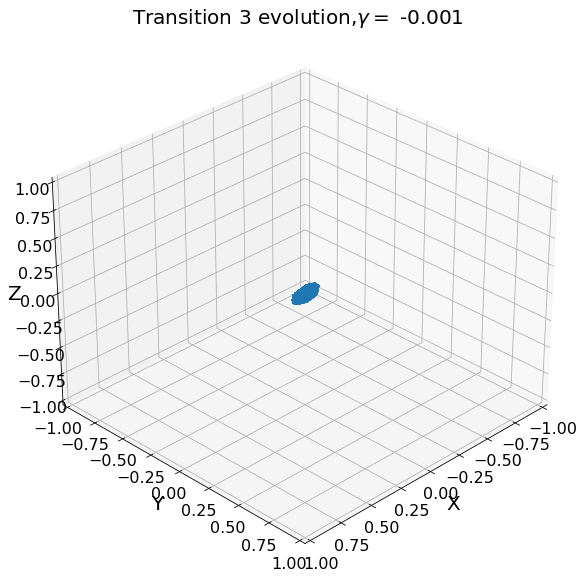

In [48]:

from matplotlib import animation
from functools import partial
#from mpl_toolkits.mplot3d import Axes3D

fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
#bg = ax.pcolor(Bx[:,:,0],By[:,:,0],np.real(Fi[:,t].reshape(pts,pts)).T,cmap='nipy_spectral',shading='auto')
#pe*=1E4
zpts,=ax.plot([],[],[],'*')
#pe=1E4/2
ax.set(xlim3d=(-2*pe, 2*pe), xlabel='X')
ax.set(ylim3d=(-2*pe, 2*pe), ylabel='Y')
ax.set(zlim3d=(-2*pe, 2*pe), zlabel='Z')
ax.view_init(azim=45, elev=30)
##pts=ax.plot()

#plt.legend()
#plt.plot(,'b.')
#bg.colorbar()
S = 2E-0
F = 1E-3
frames = 200
tau = -frames/np.log(F/S)
tauo = frames/np.log(S-F+1)
m=(F-S)/-frames
#frames = 200
t=3
ax.set(title="Transition %s evolution"%t)


SA = lambda f: S*np.exp(-f/tau)
SAo = lambda f: (S-np.exp(f/tauo)+1)
SAl =lambda f: S-m*f
#plt.plot(Bxi,Fi[:,t],'*-')
#
global Bf
#Bsi = 
Bf=np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T
#Bf=BZP

def init():
    #pass
    #ax.set_xlim(-5,5)
    #ax.set_ylim(-5,5)
    #zpts,=ax.plot([],[],'*')
    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])

    #pts.set_data(Bf[:,0],Bf[:,1]) 
    return zpts,

def update(frame):
    global Bf
    g=-SA(frame)
    ax.set(title="Transition %s evolution,$\gamma=$ %s"%(t,np.around(g,3)))

    zpts.set_data(Bf[:,0],Bf[:,1])
    zpts.set_3d_properties(Bf[:,2])
    # F,Fp,Fpp=sweep(Bf)
    #F,Fp,Fpp=sweepSingleTrans(Bf,0,2)
    
    F,Fp=sweepNoCurve(Bf)
    # Bf = NewtonMethodStep(Bf,Fp[:,t,:],Fpp[:,t,:,:],gamma=1,th=1E4)
    #Bf = NewtonMethodStep(Bf,Fp,Fpp,gamma=0.1,th=1E4)
    
    Bf=GradientDescentStep(Bf,Fp,t,gamma=g)
    #print(frame)
    return zpts,

ani=animation.FuncAnimation(fig,update,init_func=init,blit=True,frames=frames,interval=1)
ani.save('test.mp4', fps=30)

#plt.show()
#plt.close()



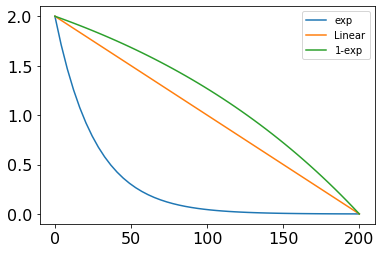

In [49]:
#plt.close()
fs = np.linspace(0,frames)
plt.plot(fs,SA(fs),label="exp")
plt.plot(fs,SAl(fs),label="Linear")
plt.plot(fs,SAo(fs),label="1-exp")
plt.legend()
plt.show()
plt.close()

In [50]:
%%script false
%matplotlib widget
#print(Bzi)

ZFP = np.unique(np.around(Bf,3),axis=0)

print("ZEFOZ points: ",ZFP*1E4)

idx=-1

z=ZFP[idx][2]#np.argwhere(Bzi==-4)
y=ZFP[idx][1]#np.argwhere(Bzi==-4)

print(z)

pts = 100
Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Bsi = np.array(np.meshgrid(Bxi,Bxi,z)).reshape(3,-1).T
print(Bsi.shape)
Ft,_,_=sweep(Bsi)


print(z)
print("Ft",Ft.shape)
fr = np.squeeze(np.real(Ft[:,t].T.reshape(pts,pts,-1)))
print("Fr",fr.shape)
print(Bx.shape,By.shape)
#plt.pcolor(Bxi,Byi,fr[:,:,1],cmap='nipy_spectral',shading='auto')
#plt.plot()
#print(BZP)


fig=plt.figure(figsize=(10,10))
#ax = plt.axes()
#fig, ax = plt.subplots()
ax=fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,np.real(fr),alpha=0.5)
ax.plot(*ZFP[idx],'*')
plt.show()
#plt.close()


Couldn't find program: 'false'


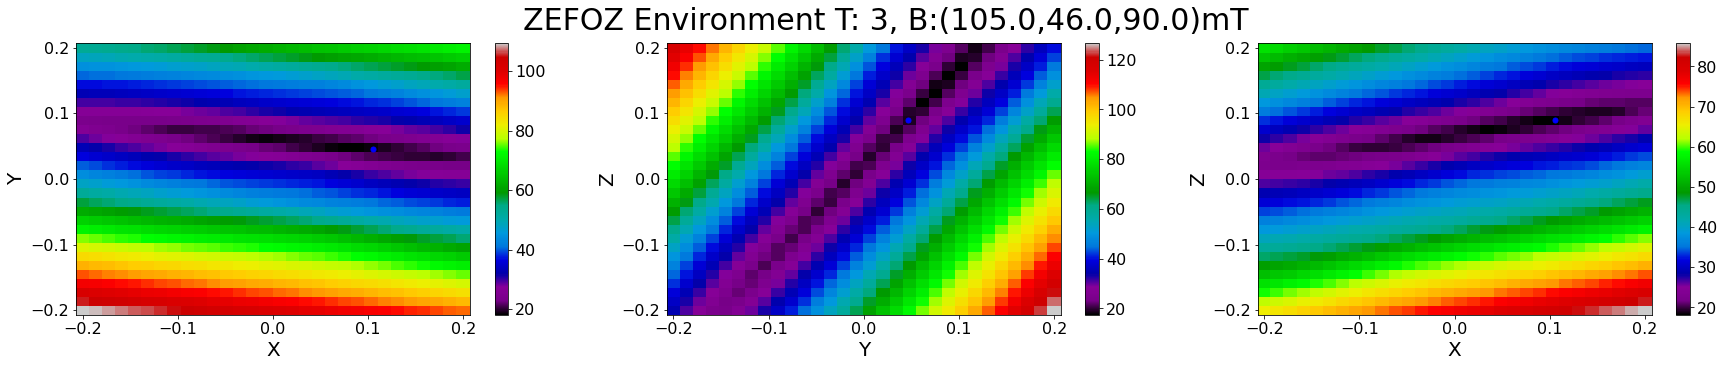

In [51]:
%matplotlib inline
ZFP = np.unique(np.around(Bf,3),axis=0)
idx = -3
#idx= -2
P=ZFP[idx]




Bxi = np.linspace(-0.2,0.2,pts)
X,Y = np.meshgrid(Bxi,Bxi)
Fxy,_=sweepNoCurve(np.array(np.meshgrid(Bxi,Bxi,P[2])).reshape(3,-1).T)
Fxy= np.squeeze(np.real(Fxy[:,t].T.reshape(pts,pts,-1)))
Fyz,_=sweepNoCurve(np.array(np.meshgrid(P[0],Bxi,Bxi)).reshape(3,-1).T)
Fyz= np.squeeze(np.real(Fyz[:,t].T.reshape(pts,pts,-1)))
Fxz,_=sweepNoCurve(np.array(np.meshgrid(Bxi,P[1],Bxi)).reshape(3,-1).T)
Fxz= np.squeeze(np.real(Fxz[:,t].T.reshape(pts,pts,-1)))



# print("Fr",fr.shape)



fig = plt.figure(figsize=(30,5))
plt.set_cmap('nipy_spectral')

marker_style = dict(color='b', marker='o',
                    markersize=5)
fig.suptitle("ZEFOZ Environment T: %s, B:(%s,%s,%s)mT"%(t,P[0]*1E3,P[1]*1E3,P[2]*1E3),fontsize=30)
ax = plt.subplot(1,3,1)
plt.pcolor(X,Y,Fxy,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[1],**marker_style)
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()

ax = plt.subplot(1,3,2)
plt.pcolor(X,Y,Fyz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[1],P[2],**marker_style)
plt.xlabel("Y")
plt.ylabel("Z")
plt.colorbar()

ax = plt.subplot(1,3,3)
plt.pcolor(X,Y,Fxz.T,cmap='nipy_spectral',shading='auto')
plt.plot(P[0],P[2],**marker_style)
plt.xlabel("X")
plt.ylabel("Z")

plt.colorbar()

#for i in range(int(Fi.shape[3]/4)):
#ax.plot_surface(X,Y,np.real(Fi[:,:,Z,T]))



#plt.legend()
# plt.savefig("../images/grad_desc_ZFcan.pdf",bbox_inches='tight')
plt.show()
plt.close()
